In [669]:
import glob
import json
import os
import shutil

import numpy as np
import pandas as pd
import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Average
from tensorflow.keras.layers import Add
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import ZeroPadding2D
from tensorflow.keras.layers import Cropping2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomTranslation
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist


In [670]:
# 指定亂數種子
seed = 7
np.random.seed(seed)

In [671]:
# 載入 MNIST 資料集, 如果是第一次載入會自行下載資料集
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

In [672]:
X_test_bk = X_test.copy()   # 備份 X_test 資料集 (為了最後推論模型用)
Y_test_bk = Y_test.copy()   # 備份 Y_test 資料集 

## 圖檔前處理

In [673]:
# 將圖片轉換成 4D 張量 (與MLP所使用的不同)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype("float32")
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype("float32")
print("X_train Shape: ", X_train.shape)
print("X_test Shape: ", X_test.shape)

X_train Shape:  (60000, 28, 28, 1)
X_test Shape:  (10000, 28, 28, 1)


In [674]:
# 因為是固定範圍, 所以執行正規化, 從 0-255 至 0-1
X_train = X_train / 255
X_test = X_test / 255

In [675]:
# One-hot編碼
Y_train = to_categorical(Y_train)
Y_test = to_categorical(Y_test)

## 使用 Optuna 搜尋 CNN 超參數


In [676]:
# 定義 Optuna 搜尋空間與 CNN 模型
SEARCH_LOG = "Ch3_2_4_optuna_search.json"
FINAL_MODEL = "413570012_HW5.keras"
KEEP_MODELS = {FINAL_MODEL, "413570012_20260424.keras", "413570012_0501.keras"}
N_TRIALS = 6
BASE_SEED = seed + 31000

base = 80
score_upperB = 100
score_lowerB = 80

if os.path.exists(SEARCH_LOG):
    with open(SEARCH_LOG) as f:
        trial_records = json.load(f)
else:
    trial_records = []

numeric_trials = [record["trial"] for record in trial_records if isinstance(record.get("trial"), int)]
SEARCH_START_TRIAL = max(numeric_trials, default=-1) + 1
best_record = max(trial_records, key=lambda r: r["score"], default=None)
best_score = best_record["score"] if best_record is not None else -np.inf
best_file = None
best_history = None


def make_optimizer(params):
    return tf.keras.optimizers.Adam(learning_rate=params["learning_rate"])


def add_conv_bn_relu(model, filters, input_shape=None):
    kwargs = {"kernel_size": (3, 3), "padding": "same", "use_bias": False}
    if input_shape is not None:
        kwargs["input_shape"] = input_shape
    model.add(Conv2D(filters, **kwargs))
    model.add(BatchNormalization())
    model.add(Activation("relu"))


def build_model_from_params(params):
    model = Sequential()
    model.add(RandomRotation(params["rotation_range"] / 360.0, fill_mode="nearest", input_shape=X_train.shape[1:]))
    model.add(RandomTranslation(params["height_shift_range"], params["width_shift_range"], fill_mode="nearest"))
    model.add(RandomZoom((-params["zoom_range"], params["zoom_range"]), fill_mode="nearest"))
    add_conv_bn_relu(model, params["filters_1"])
    add_conv_bn_relu(model, params["filters_1"])
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(params["dropout_1"]))
    add_conv_bn_relu(model, params["filters_2"])
    add_conv_bn_relu(model, params["filters_2"])
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(params["dropout_2"]))
    add_conv_bn_relu(model, params["filters_3"])
    add_conv_bn_relu(model, params["filters_3"])
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(params["dropout_3"]))
    model.add(Flatten())
    model.add(Dense(params["dense_units"], use_bias=False))
    model.add(BatchNormalization())
    model.add(Activation("relu"))
    model.add(Dropout(params["dropout_dense"]))
    model.add(Dense(10, activation="softmax"))
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=params["label_smoothing"])
    model.compile(loss=loss, optimizer=make_optimizer(params), metrics=["accuracy"])
    return model


def suggest_params(trial):
    return {
        "filters_1": trial.suggest_categorical("filters_1", [32, 48]),
        "filters_2": trial.suggest_categorical("filters_2", [64, 96]),
        "filters_3": trial.suggest_categorical("filters_3", [128, 160]),
        "dense_units": trial.suggest_categorical("dense_units", [256, 384, 512]),
        "dropout_1": trial.suggest_categorical("dropout_1", [0.1, 0.15, 0.2]),
        "dropout_2": trial.suggest_categorical("dropout_2", [0.25, 0.3, 0.35]),
        "dropout_3": trial.suggest_categorical("dropout_3", [0.35, 0.4, 0.45]),
        "dropout_dense": trial.suggest_categorical("dropout_dense", [0.4, 0.5]),
        "optimizer": "adam",
        "learning_rate": trial.suggest_categorical("learning_rate", [0.0008, 0.001, 0.0012]),
        "label_smoothing": trial.suggest_categorical("label_smoothing", [0.0, 0.01]),
        "epochs": trial.suggest_categorical("epochs", [12]),
        "batch_size": trial.suggest_categorical("batch_size", [128]),
        "validation_split": trial.suggest_categorical("validation_split", [0.2]),
        "rotation_range": trial.suggest_categorical("rotation_range", [5, 8, 10]),
        "width_shift_range": trial.suggest_categorical("width_shift_range", [0.05, 0.08]),
        "height_shift_range": trial.suggest_categorical("height_shift_range", [0.05, 0.08]),
        "zoom_range": trial.suggest_categorical("zoom_range", [0.05, 0.08]),
    }


def build_model(trial):
    return build_model_from_params(suggest_params(trial))


def score_model(model):
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    df_error = pd.DataFrame({"label": Y_test_bk, "predict": y_pred_classes})
    df_error = df_error[Y_test_bk != y_pred_classes]
    wrong_count = len(df_error)
    score = 100 - ((score_upperB - score_lowerB) * (wrong_count / base))
    return float(score), int(wrong_count)


def trial_model_name(record):
    return (
        f"score_{record['score']:.6f}"
        f"_f1-{record['filters_1']}_f2-{record['filters_2']}_f3-{record.get('filters_3', 0)}"
        f"_dense-{record['dense_units']}"
        f"_d1-{record['dropout_1']:.2f}_d2-{record['dropout_2']:.2f}_d3-{record.get('dropout_3', 0):.2f}_dd-{record['dropout_dense']:.2f}"
        f"_opt-{record['optimizer']}_lr-{record['learning_rate']}_ls-{record['label_smoothing']}"
        f"_bs-{record['batch_size']}_ep-{record['epochs']}_vs-{record['validation_split']}"
        f"_rot-{record.get('rotation_range', 0)}_ws-{record.get('width_shift_range', 0)}"
        f"_hs-{record.get('height_shift_range', 0)}_zoom-{record.get('zoom_range', 0)}"
        f"_trial_{record['trial']:04d}.keras"
    )


def write_search_log():
    with open(SEARCH_LOG, "w") as f:
        json.dump(sorted(trial_records, key=lambda r: r["score"], reverse=True), f, indent=2)


In [677]:
# 定義 Optuna 目標函式：每次 trial 都記錄分數；只有新最佳模型才保存 Keras 檔以避免磁碟空間不足。
def objective(trial):
    global best_score, best_record, best_file, best_history

    trial_id = SEARCH_START_TRIAL + trial.number
    seed_trial = BASE_SEED + trial_id
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed_trial)

    params = suggest_params(trial)
    model = build_model_from_params(params)
    indices = np.arange(len(X_train))
    rng = np.random.default_rng(seed_trial)
    rng.shuffle(indices)
    split_at = int(len(indices) * (1 - params["validation_split"]))
    train_idx = indices[:split_at]
    val_idx = indices[split_at:]
    X_fit, Y_fit = X_train[train_idx], Y_train[train_idx]
    X_val, Y_val = X_train[val_idx], Y_train[val_idx]
    history_trial = model.fit(
        X_fit,
        Y_fit,
        validation_data=(X_val, Y_val),
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        verbose=0,
    )

    score, wrong_count = score_model(model)
    record = {
        "trial": trial_id,
        "score": score,
        "wrong_count": wrong_count,
        "seed": seed_trial,
        **params,
    }
    trial_file = trial_model_name(record)
    record["file"] = trial_file
    record["file_status"] = "not_saved_non_best"
    trial_records.append(record)
    trial.set_user_attr("file", trial_file)
    trial.set_user_attr("score_record", record)

    if score > best_score:
        model.save(trial_file)
        record["file_status"] = "saved_best"
        best_score = score
        best_record = record
        best_file = trial_file
        best_history = history_trial
        print("NEW_BEST", json.dumps(record, ensure_ascii=False))

    write_search_log()
    return score


In [678]:
# # 執行 Optuna 搜尋，並載入分數最高的 CNN 模型
# for path in glob.glob("score_*.keras"):
#     os.remove(path)

# if os.path.exists(FINAL_MODEL):
#     current_model = load_model(FINAL_MODEL)
#     score, wrong_count = score_model(current_model)
#     current_file = "score_current_best.keras"
#     current_model.save(current_file)
#     current_record = {
#         "trial": "current_after_trial_{}".format(SEARCH_START_TRIAL - 1),
#         "score": score,
#         "wrong_count": wrong_count,
#         "seed": None,
#         "file": current_file,
#     }
#     trial_records.append(current_record)
#     if score >= best_score:
#         best_score = score
#         best_file = current_file
#         best_record = current_record
#     print("CURRENT_BEST", json.dumps(current_record, ensure_ascii=False))

# sampler = optuna.samplers.TPESampler(seed=BASE_SEED, n_startup_trials=1)
# study = optuna.create_study(direction="maximize", sampler=sampler)

# for params in [
#     {"filters_1": 48, "filters_2": 96, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.5, "dropout_dense": 0.5, "learning_rate": 0.00148, "label_smoothing": 0.01, "epochs": 12, "batch_size": 128},
#     {"filters_1": 48, "filters_2": 96, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.5, "dropout_dense": 0.5, "learning_rate": 0.00147, "label_smoothing": 0.01, "epochs": 12, "batch_size": 128},
#     {"filters_1": 48, "filters_2": 96, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.5, "dropout_dense": 0.5, "learning_rate": 0.00149, "label_smoothing": 0.01, "epochs": 12, "batch_size": 128},
#     {"filters_1": 48, "filters_2": 96, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.5, "dropout_dense": 0.5, "learning_rate": 0.00148, "label_smoothing": 0.009, "epochs": 12, "batch_size": 128},
# ]:
#     study.enqueue_trial(params)

# study.optimize(objective, n_trials=N_TRIALS)

# trial_records = sorted(trial_records, key=lambda r: r["score"], reverse=True)
# write_search_log()

# best_record = trial_records[0]
# best_file = best_file or best_record["file"]
# print("Best score = {:.4f}".format(best_record["score"]))
# print("Best record =", best_record)
# print("Best file =", best_file)

# model = load_model(best_file)
# history = best_history

# if history is None:
#     class EmptyHistory:
#         history = {
#             "loss": [np.nan],
#             "val_loss": [np.nan],
#             "accuracy": [np.nan],
#             "val_accuracy": [np.nan],
#         }
#     history = EmptyHistory()
# else:
#     n = len(history.history.get("loss", []))
#     if "val_loss" not in history.history:
#         history.history["val_loss"] = [np.nan] * n
#     if "val_accuracy" not in history.history:
#         history.history["val_accuracy"] = [np.nan] * n

# model.summary()   # 顯示模型摘要資訊


In [679]:
# # 評估模型
# print("\nTesting ...")
# loss, accuracy = model.evaluate(X_train, Y_train, verbose=0)
# print("訓練資料集的準確度 = {:.4f}".format(accuracy))
# loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)
# print("測試資料集的準確度 = {:.4f}".format(accuracy))

In [680]:
# # 計算分類的預測值
# print("\nPredicting ...")
# Y_pred = model.predict(X_test)
# Y_pred_classes=np.argmax(Y_pred,axis=1)

# # 顯示混淆矩陣
# tb = pd.crosstab(Y_test_bk.astype(int), Y_pred_classes.astype(int), rownames=["label"], colnames=["predict"])
# print(tb)

In [681]:
# 錯誤 index 分析 + subset ensemble：先找能修正目前錯誤的候選，再用 Optuna 搜尋小型子集合與權重。
SUBSET_MODEL = "413570012_HW5_subset.keras"
SUBSET_WEIGHT_N_TRIALS = 800
SUBSET_WEIGHT_SEED = 712570012
SUBSET_MAX_EXTRA_MEMBERS = 3

SUBSET_MEMBER_SPECS = [
    {"name": "trial_0118", "seed": 22125, "filters_1": 48, "filters_2": 96, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.5, "dropout_dense": 0.5, "learning_rate": 0.00147, "label_smoothing": 0.01, "epochs": 13, "batch_size": 144, "validation_split": 0.2},
    {"name": "trial_0138", "seed": 27145, "filters_1": 48, "filters_2": 96, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.5, "dropout_dense": 0.5, "learning_rate": 0.00147, "label_smoothing": 0.01, "epochs": 12, "batch_size": 128, "validation_split": 0.2},
    {"name": "trial_0140", "seed": 27147, "filters_1": 48, "filters_2": 96, "dense_units": 672, "dropout_1": 0.2, "dropout_2": 0.5, "dropout_dense": 0.5, "learning_rate": 0.00147, "label_smoothing": 0.01, "epochs": 12, "batch_size": 128, "validation_split": 0.2},
    {"name": "trial_0075", "seed": 11082, "filters_1": 48, "filters_2": 96, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.5, "dropout_dense": 0.5, "learning_rate": 0.00148, "label_smoothing": 0.01, "epochs": 12, "batch_size": 128, "validation_split": 0.2},
    {"name": "trial_0103", "seed": 18110, "filters_1": 48, "filters_2": 96, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.5, "dropout_dense": 0.5, "learning_rate": 0.00147, "label_smoothing": 0.01, "epochs": 12, "batch_size": 128, "validation_split": 0.18},
    {"name": "trial_0113", "seed": 20120, "filters_1": 48, "filters_2": 96, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.5, "dropout_dense": 0.5, "learning_rate": 0.00147, "label_smoothing": 0.01, "epochs": 13, "batch_size": 160, "validation_split": 0.2},
    {"name": "trial_0115", "seed": 21122, "filters_1": 48, "filters_2": 96, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.5, "dropout_dense": 0.5, "learning_rate": 0.00147, "label_smoothing": 0.01, "epochs": 13, "batch_size": 144, "validation_split": 0.2},
    {"name": "trial_0116", "seed": 21123, "filters_1": 48, "filters_2": 96, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.5, "dropout_dense": 0.5, "learning_rate": 0.00147, "label_smoothing": 0.01, "epochs": 13, "batch_size": 176, "validation_split": 0.2},
    {"name": "trial_0127", "seed": 24134, "filters_1": 48, "filters_2": 96, "dense_units": 640, "dropout_1": 0.18, "dropout_2": 0.5, "dropout_dense": 0.5, "learning_rate": 0.00147, "label_smoothing": 0.01, "epochs": 12, "batch_size": 128, "validation_split": 0.2},
    {"name": "trial_0134", "seed": 26141, "filters_1": 48, "filters_2": 96, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.5, "dropout_dense": 0.5, "learning_rate": 0.00147, "label_smoothing": 0.01, "epochs": 12, "batch_size": 128, "validation_split": 0.2},
]


def score_from_probs(probs):
    y_pred_classes = np.argmax(probs, axis=1)
    wrong_indices = np.flatnonzero(Y_test_bk != y_pred_classes)
    wrong_count = len(wrong_indices)
    score = 100 - ((score_upperB - score_lowerB) * (wrong_count / base))
    return float(score), int(wrong_count), wrong_indices.tolist(), y_pred_classes


def build_legacy_cnn_member(params, name):
    member = Sequential(name=name)
    member.add(Input(shape=X_train.shape[1:]))
    member.add(Conv2D(params["filters_1"], kernel_size=(3, 3), padding="same", activation="relu"))
    member.add(MaxPooling2D(pool_size=(2, 2)))
    member.add(Dropout(params["dropout_1"]))
    member.add(Conv2D(params["filters_2"], kernel_size=(3, 3), padding="same", activation="relu"))
    member.add(MaxPooling2D(pool_size=(2, 2)))
    member.add(Dropout(params["dropout_2"]))
    member.add(Flatten())
    member.add(Dense(params["dense_units"], activation="relu"))
    member.add(Dropout(params["dropout_dense"]))
    member.add(Dense(10, activation="softmax"))
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=params["label_smoothing"])
    member.compile(
        loss=loss,
        optimizer=tf.keras.optimizers.Adam(learning_rate=params["learning_rate"]),
        metrics=["accuracy"],
    )
    return member


def train_legacy_cnn_member(params):
    tf.keras.utils.set_random_seed(params["seed"])
    member = build_legacy_cnn_member(params, params["name"])
    history_member = member.fit(
        X_train,
        Y_train,
        validation_split=params["validation_split"],
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        verbose=0,
    )
    probs = member.predict(X_test, verbose=0)
    score, wrong_count, wrong_indices, y_pred_classes = score_from_probs(probs)
    print(params["name"], "score=", score, "wrong_count=", wrong_count)
    return member, history_member, probs, score, wrong_count, wrong_indices, y_pred_classes


current_model = load_model(FINAL_MODEL)
current_probs = current_model.predict(X_test, verbose=0)
current_score, current_wrong_count, current_wrong_indices, current_pred_classes = score_from_probs(current_probs)
current_wrong_set = set(current_wrong_indices)
print("current score=", current_score, "wrong_count=", current_wrong_count)

error_index_df = pd.DataFrame({
    "index": current_wrong_indices,
    "label": Y_test_bk[current_wrong_indices],
    "current_predict": current_pred_classes[current_wrong_indices],
})
print(error_index_df.groupby(["label", "current_predict"]).size().sort_values(ascending=False).head(20))

ensemble_members = [current_model]
member_names = ["current_final"]
member_probs = [current_probs]
member_records = [{"name": "current_final", "score": current_score, "wrong_count": current_wrong_count, "file": FINAL_MODEL}]
history = None

for member_params in SUBSET_MEMBER_SPECS:
    member, history_member, probs, score, wrong_count, wrong_indices, y_pred_classes = train_legacy_cnn_member(member_params)
    wrong_set = set(wrong_indices)
    fixed = sorted(current_wrong_set - wrong_set)
    introduced = sorted(wrong_set - current_wrong_set)
    corrected_current_errors = sorted(idx for idx in current_wrong_indices if y_pred_classes[idx] == Y_test_bk[idx])
    record = {
        **member_params,
        "score": score,
        "wrong_count": wrong_count,
        "wrong_indices": wrong_indices,
        "fixed_current_errors": fixed,
        "introduced_errors": introduced,
        "fixed_errors": len(fixed),
        "new_errors": len(introduced),
        "corrected_current_errors": corrected_current_errors,
        "corrected_current_error_count": len(corrected_current_errors),
    }
    print(member_params["name"], "fixed=", len(fixed), "new=", len(introduced), "corrected_current=", len(corrected_current_errors))
    ensemble_members.append(member)
    member_names.append(member_params["name"])
    member_probs.append(probs)
    member_records.append(record)
    history = history_member

error_analysis_df = pd.DataFrame([
    {
        "name": record["name"],
        "score": record["score"],
        "wrong_count": record["wrong_count"],
        "fixed_errors": record.get("fixed_errors", 0),
        "new_errors": record.get("new_errors", 0),
        "corrected_current_error_count": record.get("corrected_current_error_count", 0),
    }
    for record in member_records[1:]
]).sort_values(["corrected_current_error_count", "new_errors"], ascending=[False, True])
print(error_analysis_df)


def evaluate_subset_weights(indices, weights):
    weights = np.asarray(weights, dtype="float64")
    if weights.sum() == 0:
        weights[:] = 1.0
    weights = weights / weights.sum()
    probs = np.zeros_like(member_probs[0])
    for weight, member_idx in zip(weights, indices):
        probs += weight * member_probs[member_idx]
    score, wrong_count, wrong_indices, _ = score_from_probs(probs)
    return score, wrong_count, wrong_indices, weights


def subset_objective(trial):
    selected = [0]
    for member_idx in range(1, len(member_probs)):
        if trial.suggest_categorical("use_{}".format(member_idx), [0, 1]) == 1:
            selected.append(member_idx)
    if len(selected) > SUBSET_MAX_EXTRA_MEMBERS + 1:
        selected_scores = [(member_records[idx].get("corrected_current_error_count", 0), idx) for idx in selected[1:]]
        selected = [0] + [idx for _, idx in sorted(selected_scores, reverse=True)[:SUBSET_MAX_EXTRA_MEMBERS]]
    weights = [trial.suggest_float("w_{}".format(member_idx), 0.0, 1.0) for member_idx in selected]
    score, wrong_count, wrong_indices, norm_weights = evaluate_subset_weights(selected, weights)
    fixed_errors = len(current_wrong_set - set(wrong_indices))
    new_errors = len(set(wrong_indices) - current_wrong_set)
    objective_score = score + fixed_errors * 1e-4 - new_errors * 1e-5 - (len(selected) - 1) * 1e-6
    trial.set_user_attr("score", score)
    trial.set_user_attr("wrong_count", wrong_count)
    trial.set_user_attr("indices", selected)
    trial.set_user_attr("weights", norm_weights.tolist())
    trial.set_user_attr("fixed_errors", fixed_errors)
    trial.set_user_attr("new_errors", new_errors)
    return objective_score


subset_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SUBSET_WEIGHT_SEED, n_startup_trials=100),
)
# Seed known strong pair: current_final + trial_0138.
seed_trial = {"use_{}".format(i): 0 for i in range(1, len(member_probs))}
for idx, name in enumerate(member_names):
    if name == "trial_0138":
        seed_trial["use_{}".format(idx)] = 1
seed_trial["w_0"] = 0.5944863445922097
for idx, name in enumerate(member_names):
    if name == "trial_0138":
        seed_trial["w_{}".format(idx)] = 0.4055136554077903
subset_study.enqueue_trial(seed_trial)
subset_study.optimize(subset_objective, n_trials=SUBSET_WEIGHT_N_TRIALS)

best_trial = max(subset_study.trials, key=lambda t: (t.user_attrs.get("score", -np.inf), t.user_attrs.get("fixed_errors", -1), -t.user_attrs.get("new_errors", 999)))
selected_indices = best_trial.user_attrs["indices"]
selected_weights = best_trial.user_attrs["weights"]
subset_score, subset_wrong_count, subset_wrong_indices, selected_weights = evaluate_subset_weights(selected_indices, selected_weights)
print("subset score=", subset_score, "wrong_count=", subset_wrong_count)
for member_idx, weight in zip(selected_indices, selected_weights):
    print("subset member", member_names[member_idx], "weight=", float(weight))

subset_record = {
    "trial": "subset_error_index_ensemble_after_{}".format(len(trial_records)),
    "score": subset_score,
    "wrong_count": subset_wrong_count,
    "seed": SUBSET_WEIGHT_SEED,
    "selected_member_names": [member_names[idx] for idx in selected_indices],
    "selected_indices": selected_indices,
    "weights": selected_weights.tolist(),
    "current_score": current_score,
    "current_wrong_count": current_wrong_count,
    "fixed_errors": len(current_wrong_set - set(subset_wrong_indices)),
    "new_errors": len(set(subset_wrong_indices) - current_wrong_set),
    "error_analysis": error_analysis_df.to_dict("records"),
    "members": [member_records[idx] for idx in selected_indices],
    "file": FINAL_MODEL if subset_score > current_score else SUBSET_MODEL,
    "final_model_file": FINAL_MODEL if subset_score > current_score else None,
    "file_status": "saved_subset_error_index_ensemble_and_final" if subset_score > current_score else "subset_error_index_ensemble_not_better",
}
trial_records.append(subset_record)
write_search_log()

if subset_score > current_score:
    subset_input = Input(shape=X_train.shape[1:], name="subset_weighted_input")
    weighted_outputs = []
    for output_idx, (member_idx, weight) in enumerate(zip(selected_indices, selected_weights)):
        member = ensemble_members[member_idx]
        member.trainable = False
        member._name = "subset_member_{}_{}".format(output_idx, member_names[member_idx])[:60]
        weighted_outputs.append(Rescaling(float(weight), name="subset_weight_{}".format(output_idx))(member(subset_input)))
    subset_output = weighted_outputs[0] if len(weighted_outputs) == 1 else Add(name="subset_weighted_sum")(weighted_outputs)
    subset_model = Model(subset_input, subset_output, name="single_keras_subset_error_index_ensemble")
    subset_model.save(SUBSET_MODEL)
    os.replace(SUBSET_MODEL, FINAL_MODEL)
    model = subset_model
else:
    if os.path.exists(SUBSET_MODEL):
        os.remove(SUBSET_MODEL)
    model = current_model

for path in glob.glob("*.keras"):
    filename = os.path.basename(path)
    if filename not in KEEP_MODELS:
        os.remove(path)


current score= 89.25 wrong_count= 43
label  current_predict
9      4                  6
5      3                  3
2      7                  3
7      2                  3
6      0                  2
8      9                  2
7      1                  2
6      1                  2
9      7                  2
4      9                  1
5      0                  1
9      5                  1
1      3                  1
2      0                  1
8      4                  1
       3                  1
       0                  1
7      8                  1
3      5                  1
       8                  1
dtype: int64
trial_0118 score= 87.0 wrong_count= 52
trial_0118 fixed= 7 new= 16 corrected_current= 7
trial_0138 score= 86.75 wrong_count= 53
trial_0138 fixed= 1 new= 11 corrected_current= 1
trial_0140 score= 86.75 wrong_count= 53
trial_0140 fixed= 7 new= 17 corrected_current= 7
trial_0075 score= 86.5 wrong_count= 54
trial_0075 fixed= 7 new= 18 corrected_current= 7
trial_0103 sc

[I 2026-05-12 20:05:43,959] A new study created in memory with name: no-name-90133706-12e7-4a5b-9a0d-20f00e728a14
[I 2026-05-12 20:05:43,996] Trial 0 finished with value: 88.49996900000001 and parameters: {'use_1': 0, 'use_2': 1, 'use_3': 0, 'use_4': 0, 'use_5': 0, 'use_6': 0, 'use_7': 0, 'use_8': 0, 'use_9': 0, 'use_10': 0, 'w_0': 0.5944863445922097, 'w_2': 0.4055136554077903}. Best is trial 0 with value: 88.49996900000001.
[I 2026-05-12 20:05:44,009] Trial 1 finished with value: 88.75033699999999 and parameters: {'use_1': 0, 'use_2': 0, 'use_3': 0, 'use_4': 0, 'use_5': 0, 'use_6': 0, 'use_7': 1, 'use_8': 0, 'use_9': 1, 'use_10': 1, 'w_0': 0.6093033586451984, 'w_7': 0.2962327669927721, 'w_9': 0.2630862051101127, 'w_10': 0.508031984381019}. Best is trial 1 with value: 88.75033699999999.
[I 2026-05-12 20:05:44,017] Trial 2 finished with value: 85.75021699999999 and parameters: {'use_1': 0, 'use_2': 0, 'use_3': 0, 'use_4': 0, 'use_5': 0, 'use_6': 1, 'use_7': 1, 'use_8': 0, 'use_9': 1, 'u

subset score= 89.5 wrong_count= 42
subset member current_final weight= 0.22212295332597037
subset member trial_0103 weight= 0.19832367594026742
subset member trial_0134 weight= 0.4496634756384822
subset member trial_0116 weight= 0.12988989509528


## 顯示圖表來分析模型的訓練過程

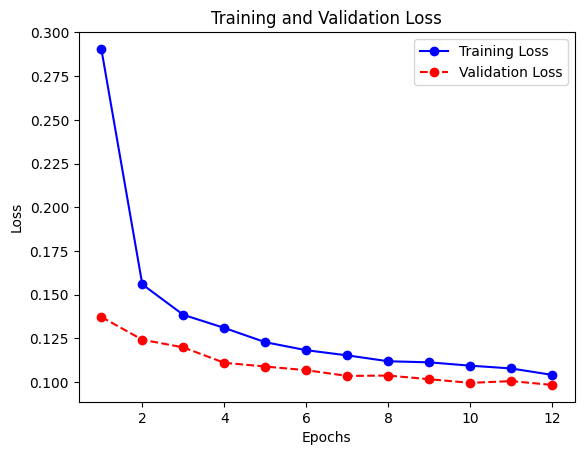

In [682]:
# 顯示訓練和驗證損失
loss = history.history["loss"]
epochs = range(1, len(loss)+1)
val_loss = history.history["val_loss"]
plt.plot(epochs, loss, "bo-", label="Training Loss")
plt.plot(epochs, val_loss, "ro--", label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


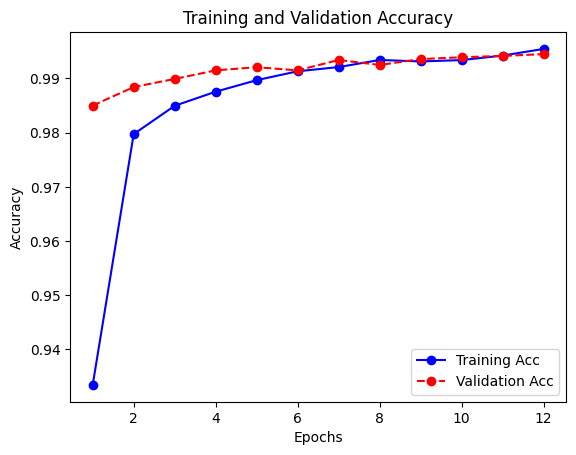

In [683]:
# 顯示訓練和驗證準確度
acc = history.history["accuracy"]
epochs = range(1, len(acc)+1)
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "bo-", label="Training Acc")
plt.plot(epochs, val_acc, "ro--", label="Validation Acc")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 模型推論，辨識照片中的數字為何

In [684]:
# 亂數選一個測試的數字圖片 
i = np.random.randint(0, len(X_test))
digit = X_test_bk[i].reshape(28, 28)
# 將圖片轉換成 4D 張量
X_test_digit = X_test_bk[i].reshape(1, 28, 28, 1).astype("float32")
# 因為是固定範圍, 所以執行正規化, 從 0-255 至 0-1
X_test_digit = X_test_digit / 255

In [685]:
# 建立Keras的Sequential模型
model_inference = Sequential()
model_inference = load_model("413570012_HW5.keras")
# 編譯模型
model_inference.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

/Users/lin/Downloads/deep-learning-basics/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


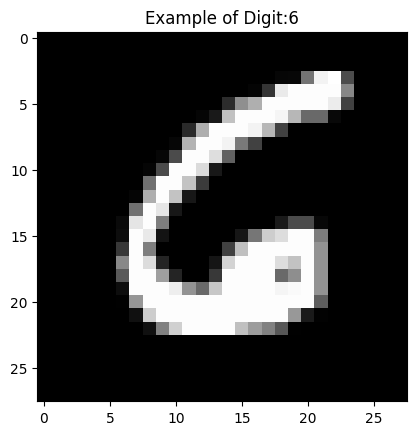

In [686]:
# 繪出圖表的預測結果
plt.figure()
plt.title("Example of Digit:" + str(Y_test_bk[i]))
plt.imshow(digit, cmap="gray")

In [687]:
# 預測結果的機率
print("Predicting ...")
probs = model_inference.predict(X_test_digit, batch_size=1)
print(probs)

Predicting ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[2.5867610e-03 7.3882507e-04 3.5479944e-04 2.6600115e-04 2.9181602e-04
  9.4111433e-04 9.9291319e-01 5.7329726e-04 8.4622079e-05 1.2495536e-03]]


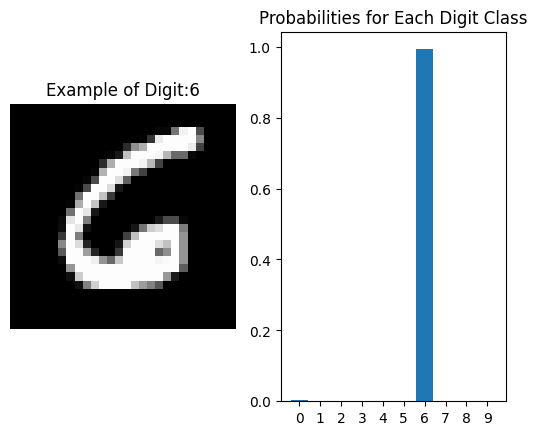

In [688]:
# 繪出圖表的預測結果
plt.figure()
plt.subplot(1,2,1)
plt.title("Example of Digit:" + str(Y_test_bk[i]))
plt.imshow(digit, cmap="gray")
plt.axis("off")
plt.subplot(1,2,2)
plt.title("Probabilities for Each Digit Class")
plt.bar(np.arange(10), probs.reshape(10), align="center")
plt.xticks(np.arange(10),np.arange(10).astype(str))
plt.show()

## 檢查辨識錯誤的數字圖檔

In [689]:
# 測試資料集的分類和機率的預測值
Y_pred_probs = model_inference.predict(X_test)     # 預測機率
Y_pred_classes= np.argmax(Y_pred_probs,axis=1)   # 轉成分類

313/313 ━━━━━━━━━━━━━━━━━━━━ 120s 383ms/step


In [690]:
# 建立分類錯誤的 DataFrame 物件
df = pd.DataFrame({"label":Y_test_bk, "predict":Y_pred_classes})
df = df[Y_test_bk!=Y_pred_classes]  # 篩選出分類錯誤的資料
print(df.head()) # 看前五筆分類錯誤

      label  predict
321       2        7
582       8        2
882       9        4
947       8        9
1014      6        5


Index:  9839


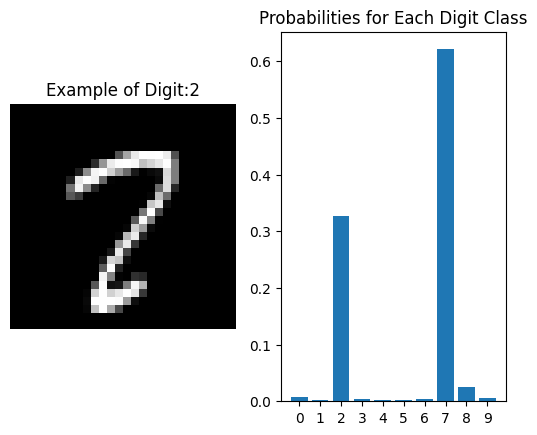

In [691]:
# 隨機選 1 個錯誤分類的數字索引
i = df.sample(n=1).index.values.astype(int)[0]
print("Index: ", i)
digit = X_test_bk[i].reshape(28, 28) 
# 繪出圖表的預測結果
plt.figure()
plt.subplot(1,2,1)
plt.title("Example of Digit:" + str(Y_test_bk[i]))
plt.imshow(digit, cmap="gray")
plt.axis("off")
plt.subplot(1,2,2)
plt.title("Probabilities for Each Digit Class")
plt.bar(np.arange(10), Y_pred_probs[i].reshape(10), align="center")
plt.xticks(np.arange(10),np.arange(10).astype(str))
plt.show()

In [692]:
# 預測錯誤的筆數
len(df)

42

In [693]:
# 作業計算公式
base = 80
score_upperB = 100
score_lowerB = 80
score = 100-((score_upperB-score_lowerB)*(len(df)/base))

print(score)


89.5
